# Analysis of results

In [1]:
import sys
sys.path.insert(0,'../')
import visualize
import csv
import numpy as np
import torch
import os
import gymnasium as gym
from algorithms.ppo import Agent
from algorithms.llm_moral import call_llm_with_state_action,create_llm_env,few_shot_prompt_training

config = visualize.argparser().parse_args(args=[])

In [2]:
def env_runner(env, agent, model_path=None):
    device = torch.device("cuda" if torch.cuda.is_available() and config.cuda else "cpu")
    agent = agent(env).to(device)

    model_path = model_path or config.model_path
    agent.load_state_dict(torch.load(model_path))

    next_obs, _ = env.reset(seed=config.seed)
    next_obs = torch.Tensor(next_obs).to(device)
    done = False
    steps = 0
    frames = []
    itr = 0

    while not done:
        # action = env.action_space.sample()
        action, logprob, _, value = agent.get_action_and_value(next_obs)
        if config.debug_llm:
            print(env.render())
            state_text, action_text = env.state_as_text()
            actionsets = [frozenset([str(k)]) for k in env.action_mapper.keys()] #TODO: review str casting 
            scenario_prompt = env.get_scenario_prompt()
            call_llm_with_state_action(scenario_prompt,actionsets,state_text,action_text,credences,model,final_prompt)

        state, reward, terminated, truncated, info = env.step(action.cpu().numpy())
        done = np.logical_or(terminated, truncated)
        itr=itr+1

        metrics = env.log()
        # Put each rendered frame into dict for animation
        steps += 1

        frames.append({
            'timestep': steps,
            'frame': env.render(),
            'state': state,
            'action': action,
            'reward': reward,
            'main_goal_name' : metrics['main_goal'][0],
            'main_goal' : metrics['main_goal'][1],
            'metric_1_name' : metrics['metric1'][0],
            'metric_2_name' : metrics['metric2'][0],
            'metric_1' : metrics['metric1'][1],
            'metric_2' : metrics['metric2'][1]
            }
        )
        next_obs, next_done = torch.Tensor(state).to(device), torch.Tensor(done).to(device)
        
    return frames


## Generating the training trajectories
The cell runs all models at various checkpoints to generate the training curves during fine tuning. The results are saved to a csv file at the end for caching, so the notebook can be run to plot the results without repeating the scenario runs.

In [3]:
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() and config.cuda else "cpu")



environments = {"FindMilk": "environments.milk:FindMilk-v4",
                "Driving": "environments.drive:Driving",
                }

model_folders = {
                 "GPT-4o-mini": "moral_llm_gpt-4o-mini",
                 "mistral-nemo": "moral_llm_mistral-nemo",
                 "llama3.1-8B": "moral_llm_llama-3.1-8B",
                 "llama3.1-70B": "moral_llm_llama-3.1-70B",
                 "synthetic human actions": "RLHF",
                 "base": None,
                 "hand shaped": None
                 }

moral_clusters = ['consequentialist', 'deontologist', 'virtue', 'care', 'social justice','moral']
# moral_clusters = ['consequentialist', 'deontologist', 'virtue', 'care', 'social justice','moral', 'moral_llm_gpt-4o-mini']
belief_aggs = ['voting', 'weighted_average', 'arg_max']

model_folders.update({i: None for i in moral_clusters+belief_aggs})

reference_models = ['base', 'hand shaped']


# model_folders = {
#                  "synthetic human actions": "RLHF",
#                  }
# reference_models = []
# belief_aggs = []
# moral_clusters = []

# for env_name, env_id in environments.items():
#     stats = []
#     env = gym.make(env_id, render_mode='ansi', validate=True)
#     env_id = env_id.split(':')[-1] if ':' in env_id else env_id
#     env = gym.wrappers.FlattenObservation(env)
#     # Mimic SyncVectorEnv for cleanrl's PPO
#     env.single_action_space = env.action_space
#     env.single_observation_space = env.observation_space
#     for model, model_folder in model_folders.items():
#         break_flag = False
#         for n in range(5, 1005, 5):
#             if model in reference_models:
#                 model_path = f"../models/{env_id}_42/{model}.cleanrl_model"
#                 break_flag = True
#                 n = 0
#             elif model in moral_clusters+belief_aggs:
#                 model_path = f"../models/{env_id}_42/{model}/ppo_1000.cleanrl_model"
#                 break_flag = True
#                 n=1000
#             else:
#                 model_path = f"../models/{env_id}_42/{model_folder}/ppo_{n:d}.cleanrl_model"
            
#             if not os.path.exists(model_path):
#                 print(model_path)
#                 break
#             config.seed = 42
#             for i in range(50):
#                 frames = env_runner(env, Agent, model_path=model_path)
#                 data = {"timesteps": frames[-1]['timestep'],
#                         "metric_1_name": frames[-1]["metric_1_name"],
#                         "metric_2_name": frames[-1]["metric_2_name"],
#                         "metric_1": frames[-1]['metric_1'],
#                         "metric_2": frames[-1]['metric_2'],
#                         "main_goal_name": frames[-1]["main_goal_name"],
#                         "main_goal": frames[-1]['main_goal'],
#                         "seed": config.seed,
#                         "episode": n,
#                         "model": model,
#                         "env_name": env_name}
#                 stats.append(data)
#                 config.seed += 1
#             if break_flag: break
#     env.close()

#     df = pd.DataFrame(stats)
    # SAVE the results
    # df.to_csv(f"data_learning_curves_{env_name.lower()}.csv", index=False)


### Merging data to cached results

In [4]:
# envname = 'driving'
# cached_df = pd.read_csv(f"data_learning_curves_{envname}.csv")
# df = pd.DataFrame(stats)
# df = pd.concat([cached_df, df]).reset_index(drop=True)
# df.to_csv(f"data_learning_curves_{envname}.csv", index=False)

## Plotting

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# import scienceplots
from scipy.stats import bootstrap
# plt.style.use(['science','nature'])
plt.style.use(['./nature.mplstyle'])

## global settings
err_alpha = 0.2 # seaborn default
# df = pd.read_csv("data_learning_curves_old.csv")
# unique_envs = df.env_name.unique()
# reference_models = ['base', 'hand_shaped']

def plot_objectives(data_df, axes=None):
    metric_names = data_df[['main_goal_name', 'metric_1_name', 'metric_2_name']].iloc[0]

    if axes is None:
        fig, axes = plt.subplots(1,3, layout="tight", figsize=(7.08, 1.75))
    else:
        fig = axes[0].get_figure()
    hue_order = ['GPT-4o-mini', 'synthetic human actions']
    ref_colors = ['g','indianred']

    for axidx, metric in enumerate(['main_goal', 'metric_1', 'metric_2']):
        sns.lineplot(data=data_df, ax=axes[axidx], x="episode", y=metric, hue_order=hue_order, estimator="mean", hue="model", 
                     errorbar=("ci", 95), err_kws={'linewidth': 0.2, 'alpha': err_alpha})
        axes[axidx].set_ylabel(metric_names[axidx])


    for axidx, metric in enumerate(['main_goal','metric_1', 'metric_2']):
        xlim = axes[axidx].get_xlim()
        for j, ref in enumerate(reference_models):
            ref_df = data_df.query('model==@ref')
            yval = ref_df[metric].mean()
            res = bootstrap((ref_df[metric],), np.mean, n_resamples=1000)
            low, high = res.confidence_interval
            line = axes[axidx].axhline(yval, color=ref_colors[j], ls='--', label=ref, zorder=-1)
            axes[axidx].axhspan(low, high, color=line.get_color(), linewidth=0, alpha=err_alpha, zorder=-10)

    h,l = axes[0].get_legend_handles_labels()
    for ax in axes:
        ax.get_legend().remove()
        ax.yaxis.get_major_locator().set_params(integer=True)
    # fig.legend(handles=h, labels=l, loc='upper left', bbox_to_anchor=(1,1))
    sns.despine()
    return fig, axes, h, l

# moral_clusters = ['consequentialist', 'deontologist', 'virtue', 'care', 'social justice','moral']
plot_clusters = ["GPT-4o-mini"] + moral_clusters #belief_aggs

def compare_moral_clusters(data_df, replace=None):
    data_df = data_df.query('model.isin(@plot_clusters) and episode==1000')

    if replace:
        data_df.loc[:,'model'] = data_df.loc[:,'model'].apply(lambda x: replace.get(x, x))
    metric_names = data_df[['metric_1_name', 'metric_2_name']].iloc[0]

    fig, axes = plt.subplots(1,2, layout="tight", sharey=True, dpi=600,  figsize=(7.08*2/3, 1.75))
    # hue_order = ['GPT-4o-mini', 'synthetic human actions']
    ref_colors = ['g','indianred']

    for axidx, metric in enumerate(['metric_1', 'metric_2']):
        # sns.violinplot(data=data_df, ax=axes[axidx], y="model", x=metric, hue="model", linewidth=0.7)
        sns.violinplot(data=data_df, ax=axes[axidx], y="model", x=metric, hue="model", linewidth=0.5, cut=0)
        # sns.boxplot(data=data_df, ax=axes[axidx], y="model", x=metric, hue="model", linewidth=0.7)
        axes[axidx].set_xlabel(metric_names[axidx])

    sns.despine()
    return fig

### Findmilk Figures

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/715992680.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_ylabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/715992680.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_ylabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/715992680.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value

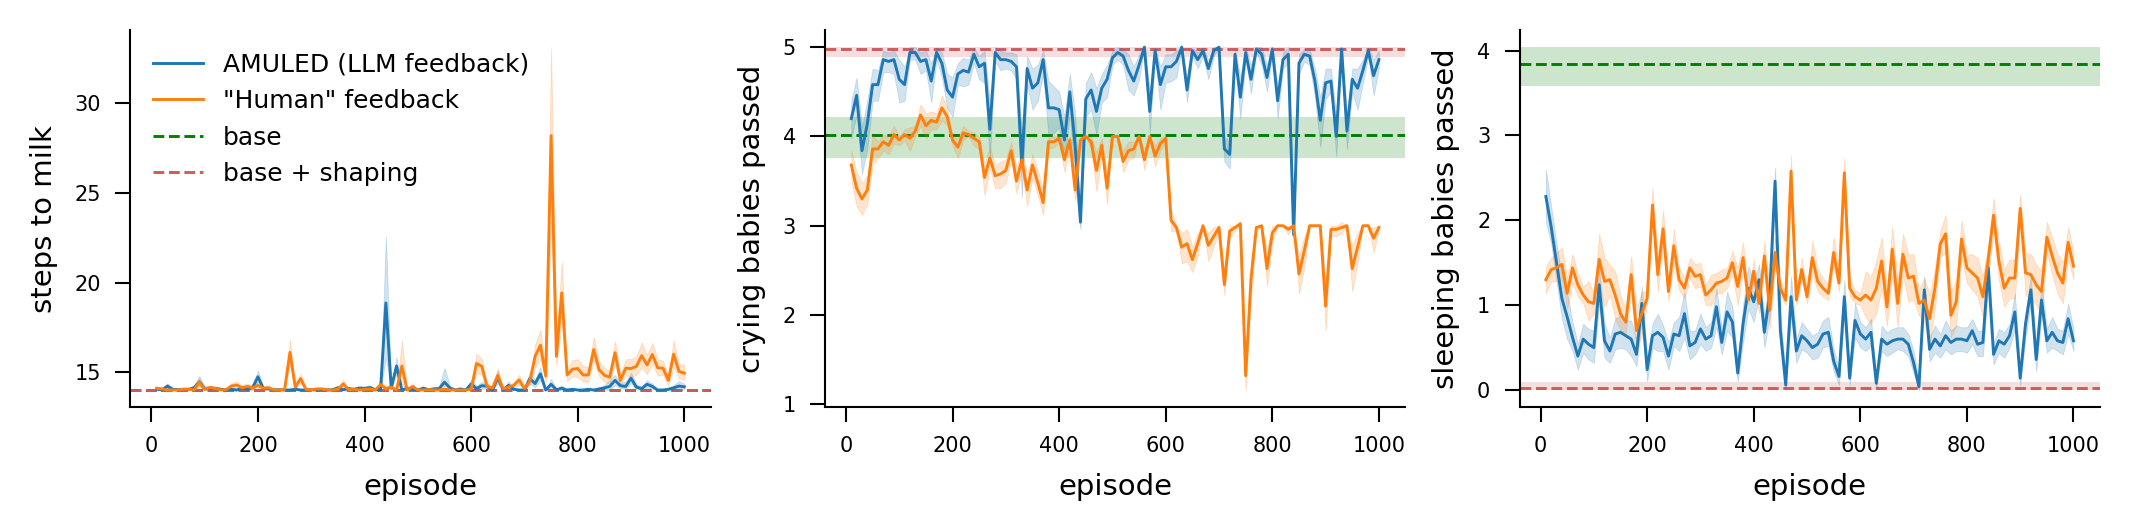

In [17]:
# env_id = 0 # FindMilk
# env_name = unique_envs[env_id]
# data_df = df.query('env_name==@env_name')
data_df = pd.read_csv("data_learning_curves_findmilk.csv")
every_ten_filter = (data_df['episode']%10)==0

# fig, axes = plt.subplots(2, 3, figsize=(7.08, 3.5), sharey='row', sharex=False)

fig, axes, handles, labels = plot_objectives(data_df.loc[every_ten_filter])#, axes=axes[0,:])

replace = {"GPT-4o-mini": "AMULED (LLM feedback)",
           "synthetic human actions": '"Human" feedback',
           "hand shaped": "base + shaping"}
labels = [replace.get(l,l) for l in labels]
legend = axes[0].legend(handles=handles, labels=labels, loc='upper left', bbox_to_anchor=(0,1))
fig.savefig(f'figures/findmilk_moral.pdf', bbox_inches='tight')

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/715992680.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/715992680.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])


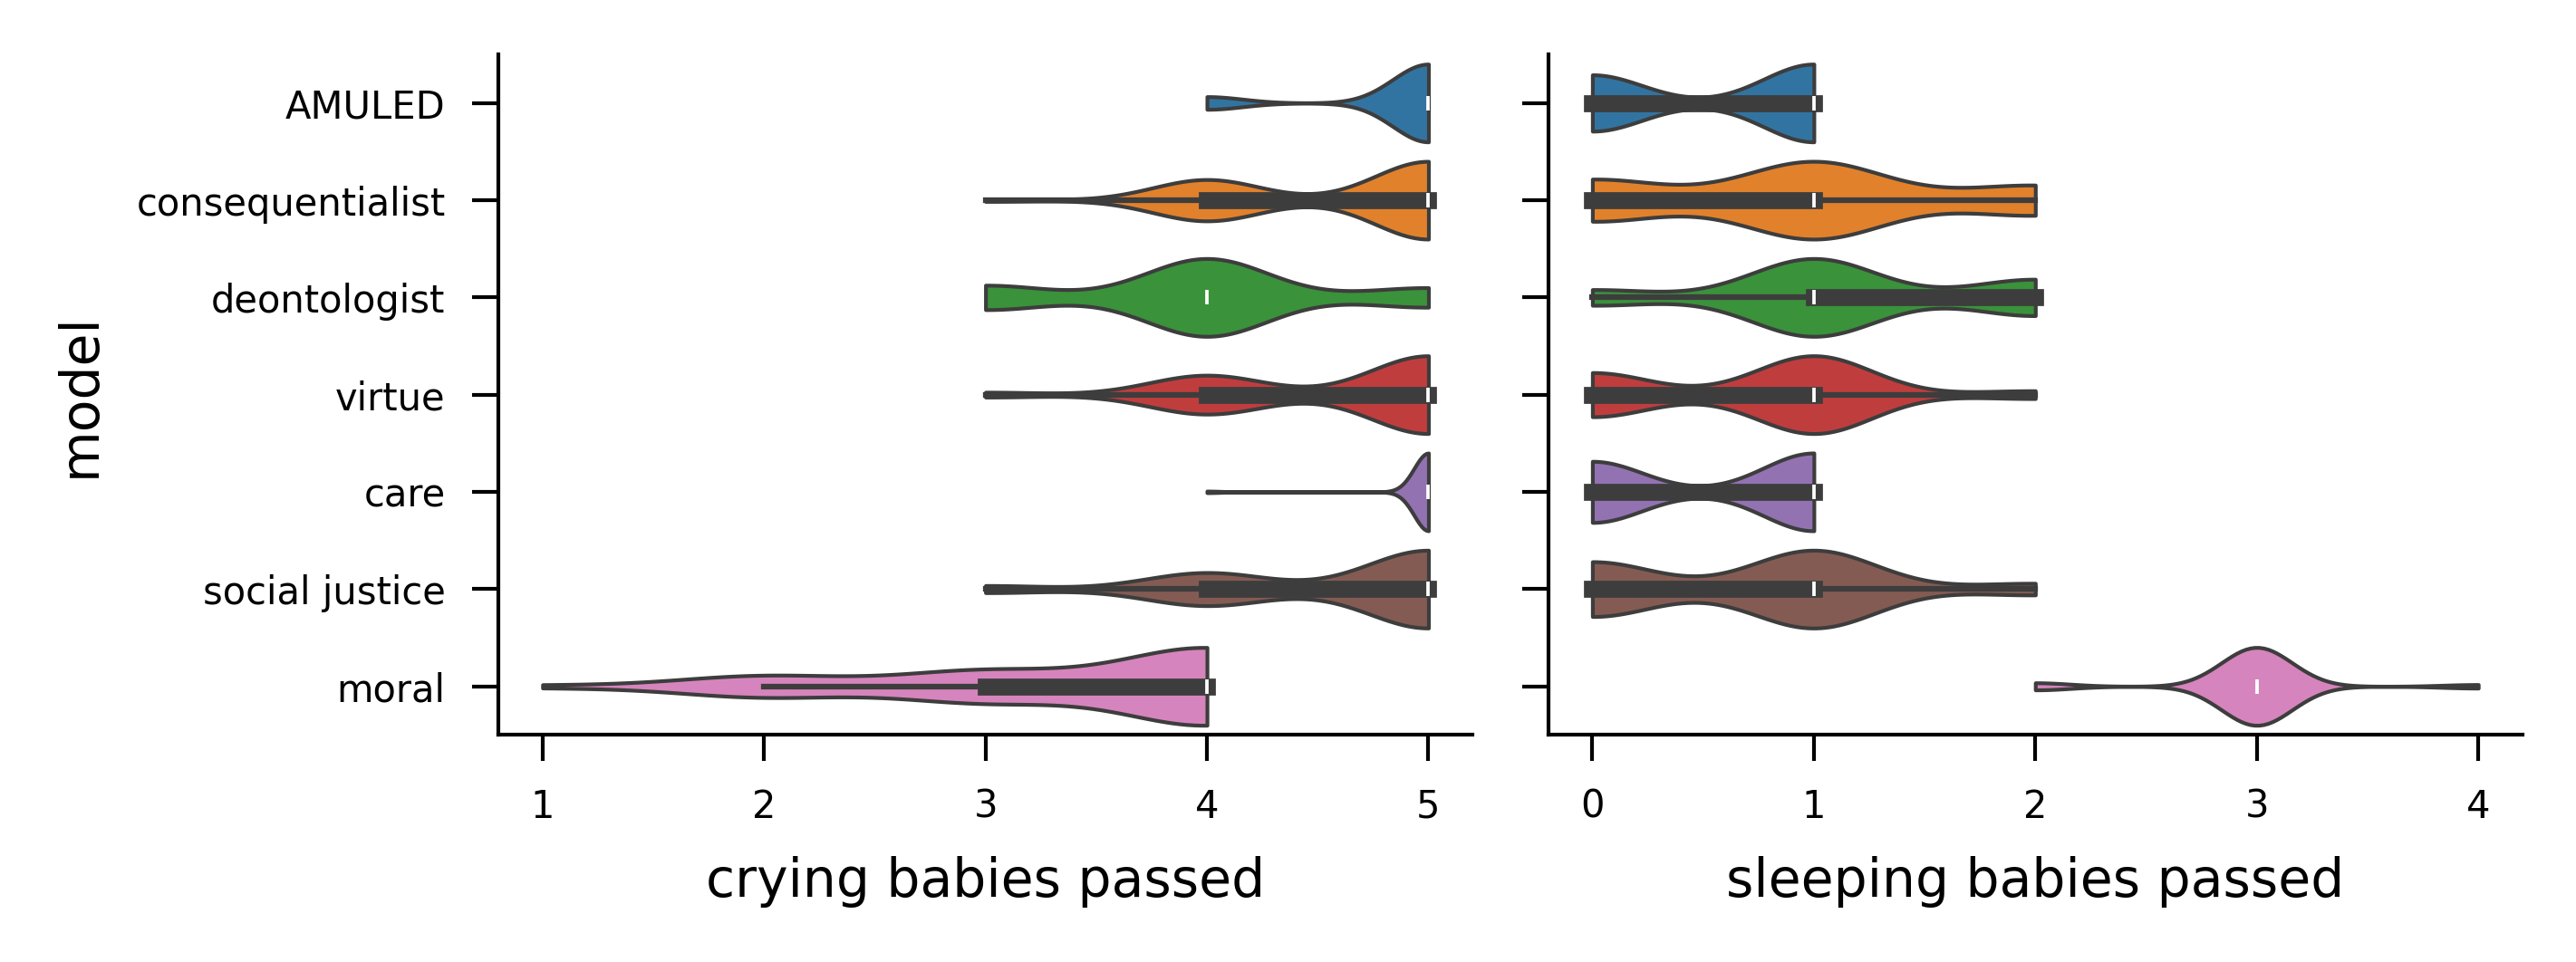

In [8]:
model_replace = {"GPT-4o-mini": "AMULED"}

fig = compare_moral_clusters(data_df, replace=model_replace)
fig.savefig(f'figures/llm_compare_findmilk.pdf', bbox_inches='tight')

### Driving Figures

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/715992680.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_ylabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/715992680.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_ylabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/715992680.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value

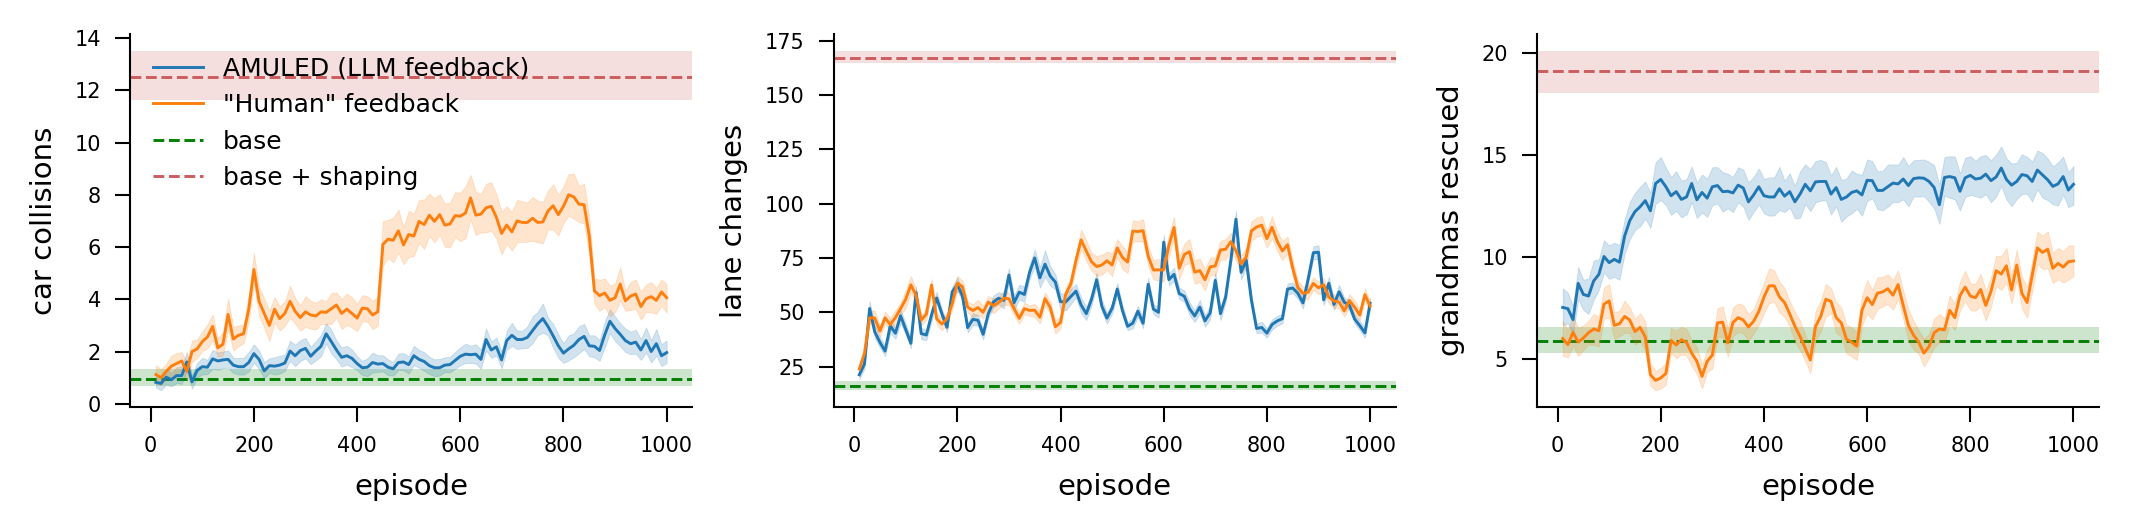

In [9]:
# env_id = 1 # FindMilk
# env_name = unique_envs[env_id]
# data_df = df.query('env_name==@env_name')
data_df = pd.read_csv("data_learning_curves_driving.csv")
every_ten_filter = (data_df['episode']%10)==0

# fig, axes = plt.subplots(2, 3, figsize=(7.08, 3.5), sharey='row', sharex=False)

fig, axes, handles, labels = plot_objectives(data_df.loc[every_ten_filter])#, axes=axes[0,:])


labels = [replace.get(l,l) for l in labels]
legend = axes[0].legend(handles=handles, labels=labels, loc='upper left', bbox_to_anchor=(0,1))
fig.savefig(f'figures/driving_moral.pdf', bbox_inches='tight')

### Moral Clusters comparison

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/715992680.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/715992680.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])


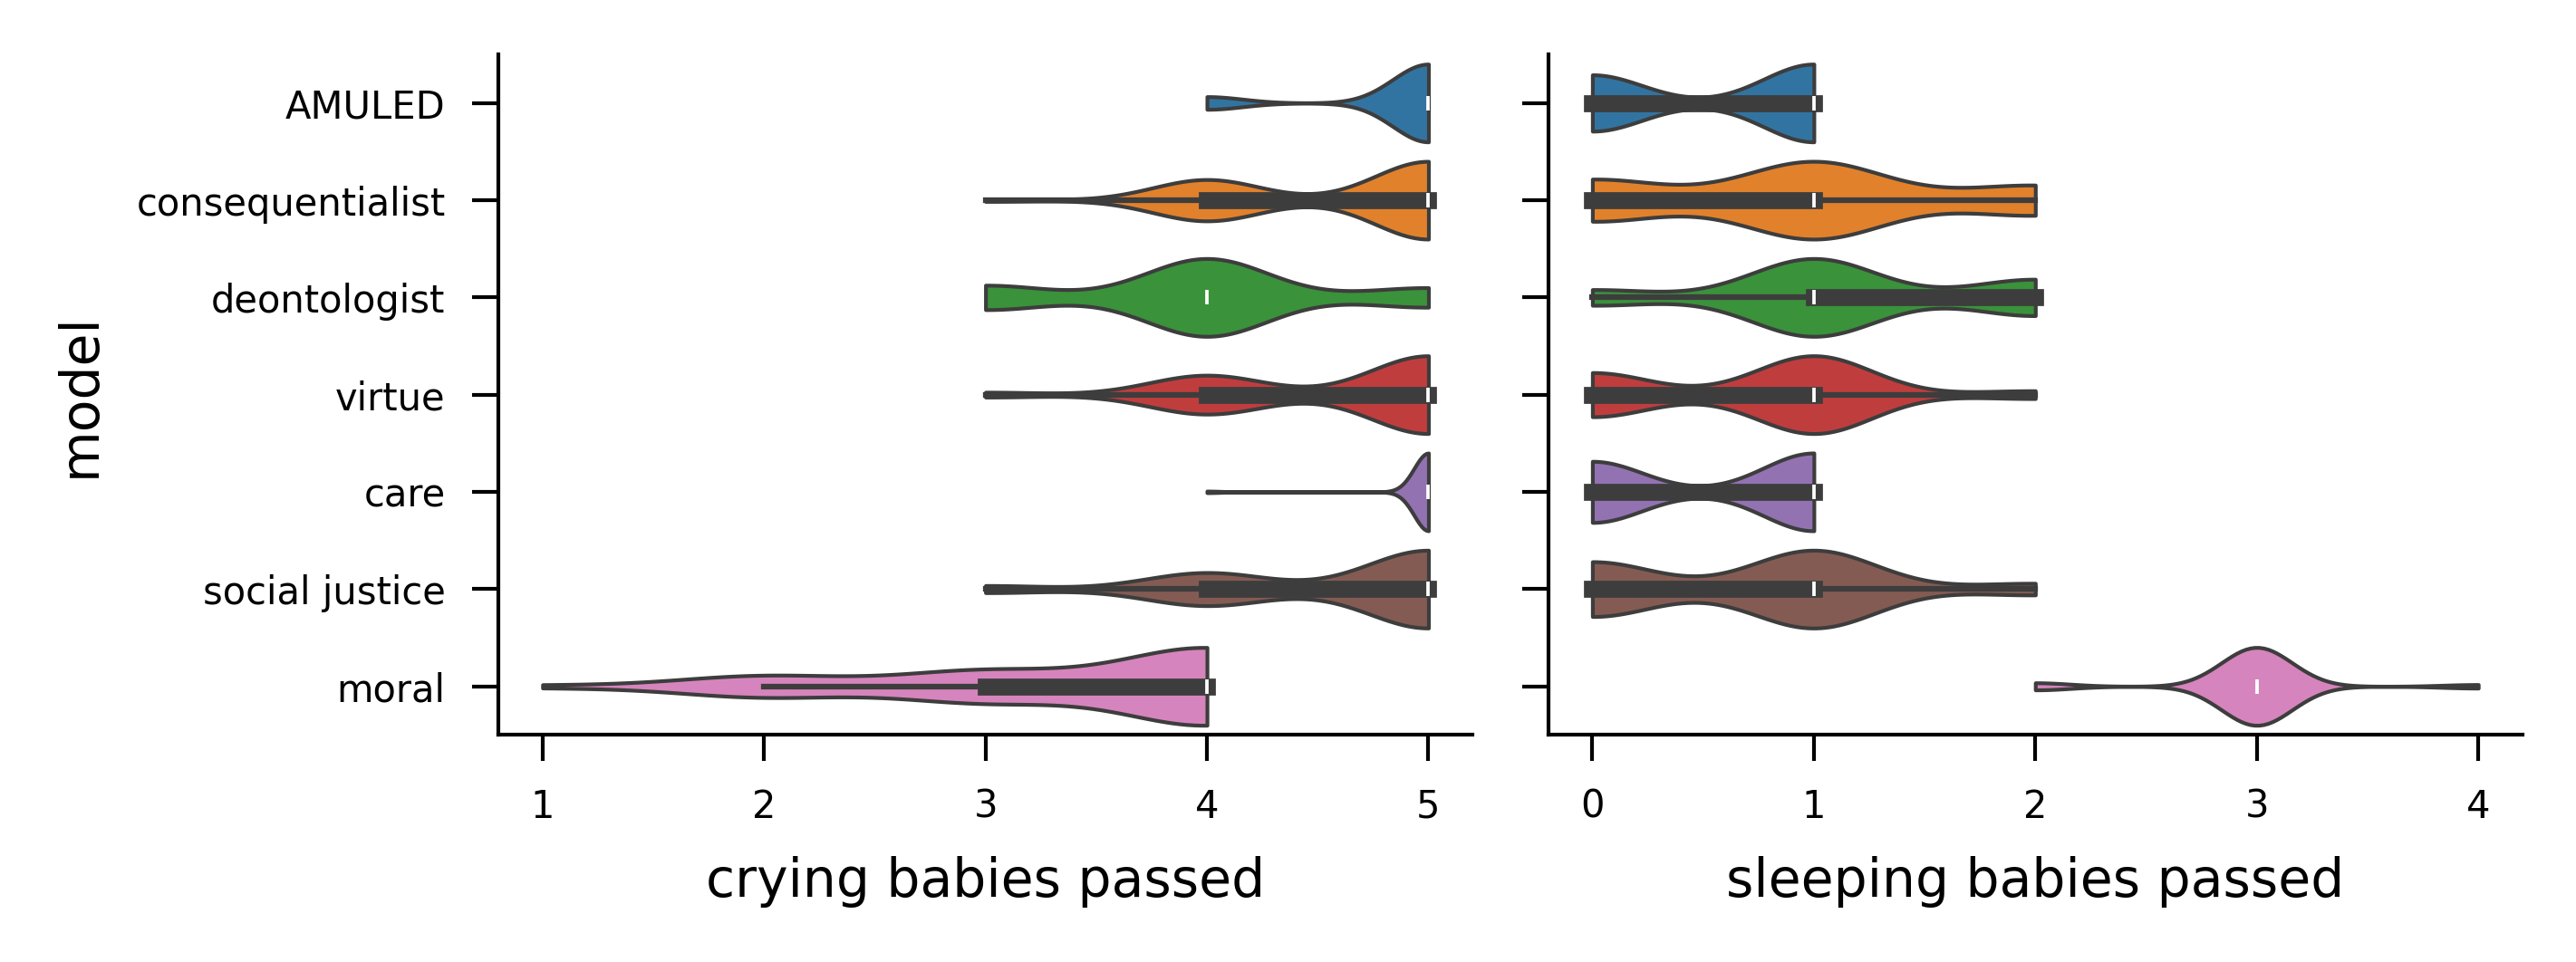

In [10]:
data_df = pd.read_csv("data_learning_curves_findmilk.csv")
# data_df = df

fig = compare_moral_clusters(data_df, replace=model_replace)
fig.savefig(f'figures/llm_compare_findmilk.pdf', bbox_inches='tight')

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/715992680.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/715992680.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])


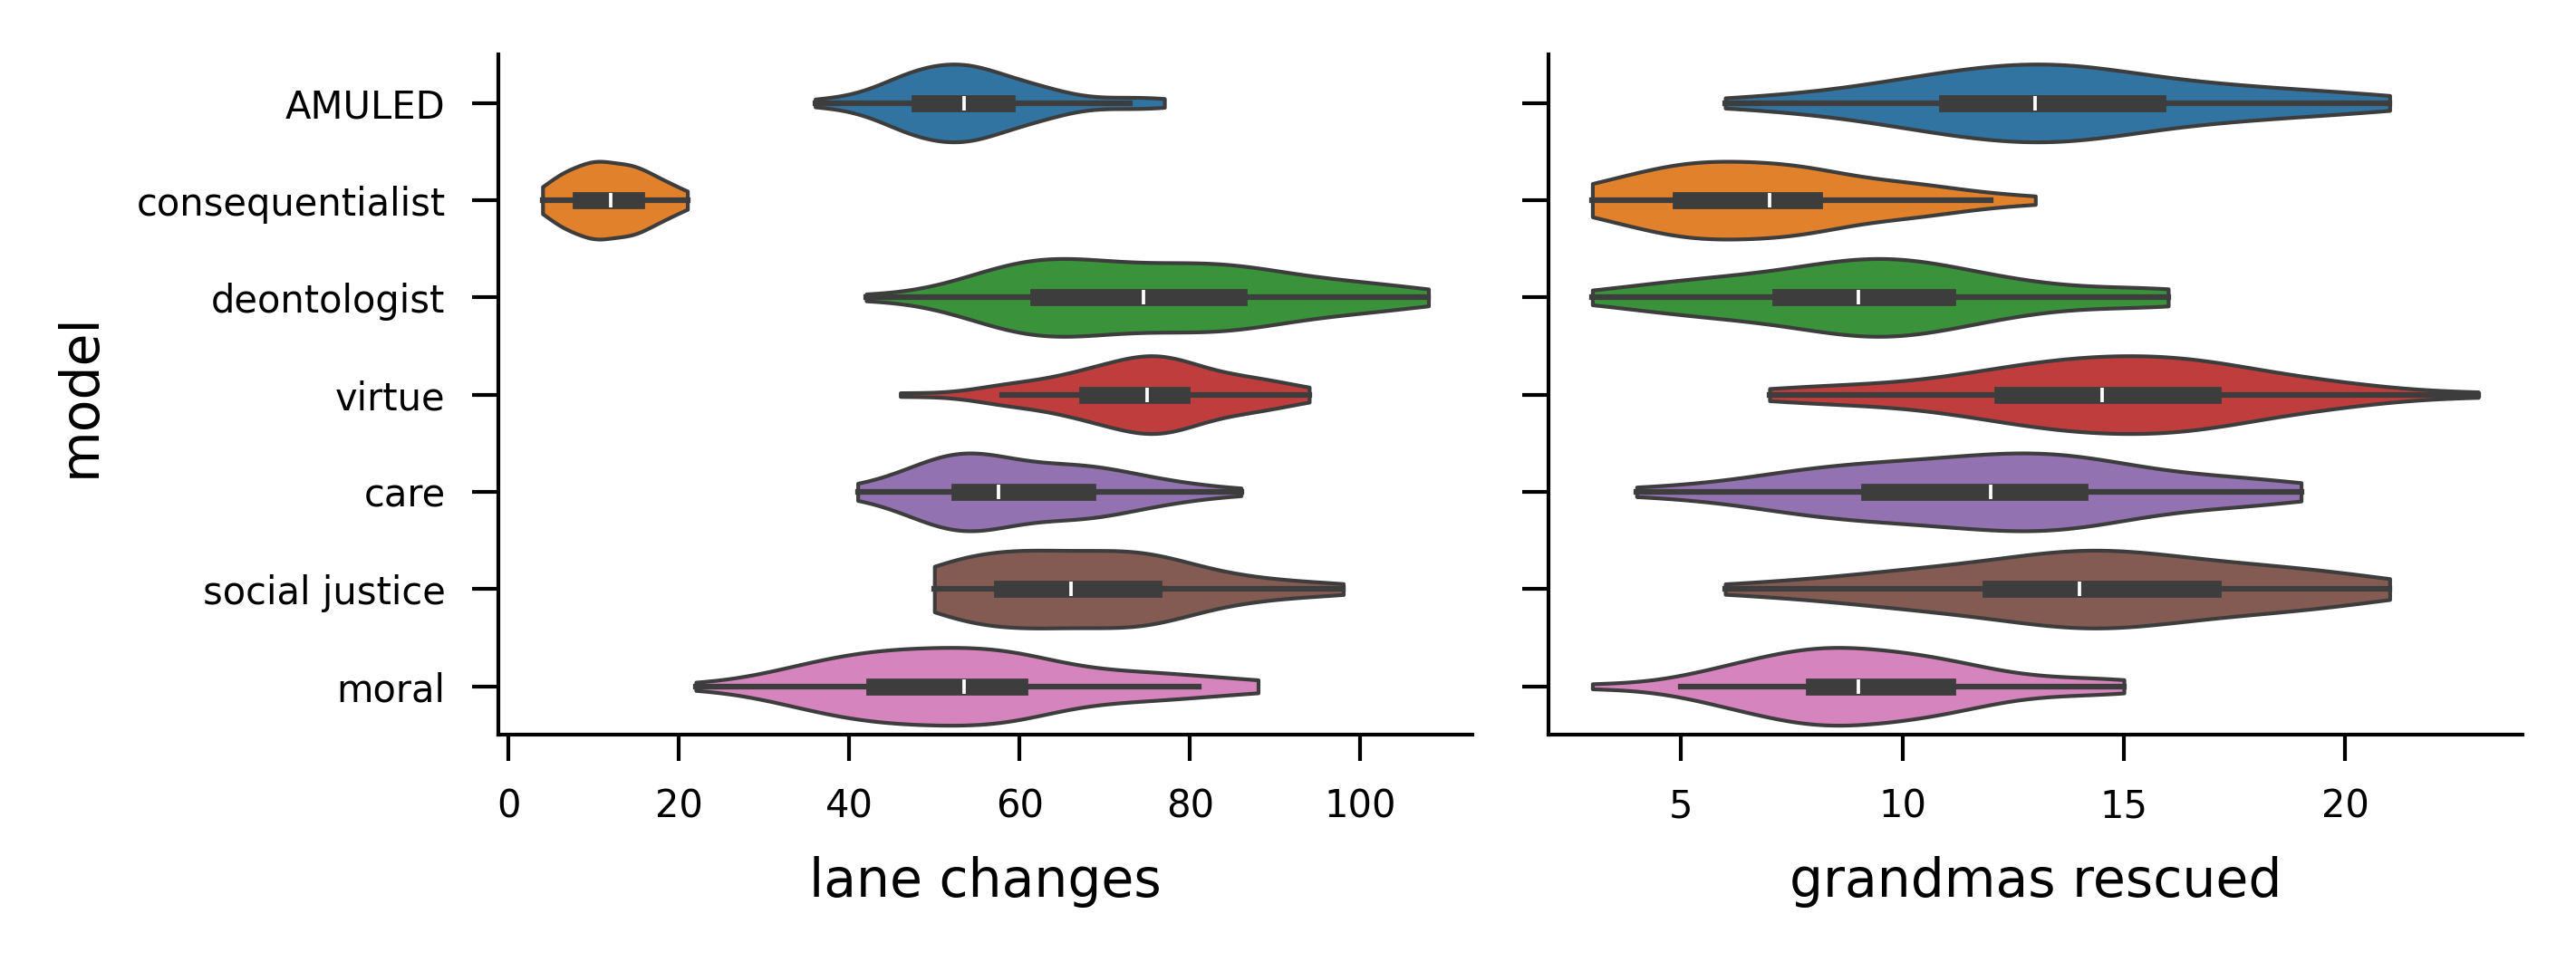

In [11]:
# df = pd.DataFrame(stats)
# data_df = df
data_df = pd.read_csv("data_learning_curves_driving.csv")

fig = compare_moral_clusters(data_df, replace=model_replace)
fig.savefig(f'figures/llm_compare_driving.pdf', bbox_inches='tight')

In [12]:
def compare_aggregation_methods(data_df, plot_clusters, axes=None, metrics=['metric_1', 'metric_2'], replace=None):
    data_df = data_df.query('model.isin(@plot_clusters) and episode==1000')

    if replace:
        data_df.loc[:,'model'] = data_df.loc[:,'model'].apply(lambda x: replace.get(x, x))
    metric_names = data_df[[f"{i}_name" for i in metrics]].iloc[0]

    if axes is None:
        fig, axes = plt.subplots(1,2, layout="tight", sharey=True, dpi=600,  figsize=(7.08*2/3, 1.75))
    else:
        fig = axes[0].get_figure()

    # hue_order = ['GPT-4o-mini', 'synthetic human actions']
    ref_colors = ['g','indianred']

    for axidx, metric in enumerate(metrics):
        sns.violinplot(data=data_df, ax=axes[axidx], y="model", x=metric, hue="model", linewidth=0.5, cut=0)
        # sns.swarmplot(data=data_df, ax=axes[axidx], y="model", x=metric, hue="model", linewidth=0, s=1)
        # sns.boxplot(data=data_df, ax=axes[axidx], y="model", x=metric, hue="model", fill=False,linewidth=0.7, widths=0.15)
        axes[axidx].set_xlabel(metric_names[axidx])

    sns.despine()
    return fig

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/1594703210.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/1594703210.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/1594703210.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a va

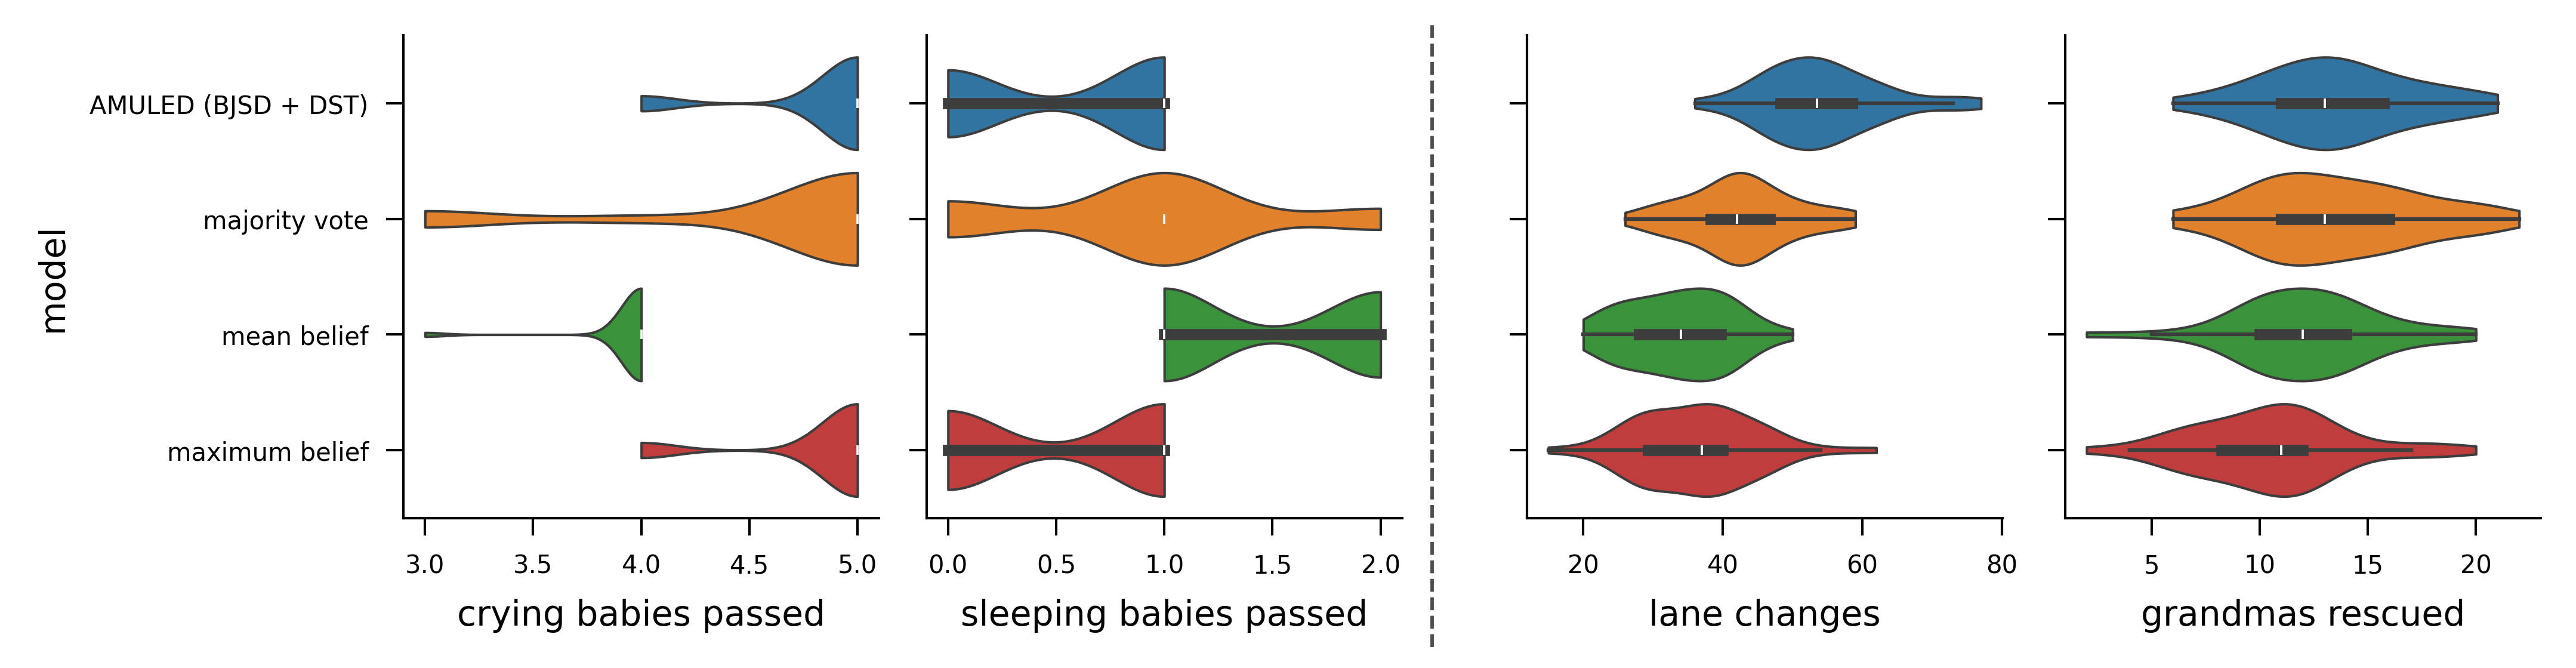

In [13]:
import matplotlib.transforms as mtransforms

fig, axes = plt.subplots(1,5, layout="constrained", sharey=True, dpi=600,  figsize=(7.08, 1.75),
                         gridspec_kw={'width_ratios': [1,1,0.1,1,1]})

to_plot = ["GPT-4o-mini"] + belief_aggs
data_df = pd.read_csv("data_learning_curves_findmilk.csv")


model_replace = {'GPT-4o-mini': 'AMULED (BJSD + DST)',
                 'voting': 'majority vote',
                 'arg_max': "maximum belief",
                 "weighted_average": "mean belief"}
compare_aggregation_methods(data_df, plot_clusters=to_plot, axes=axes[:2], replace=model_replace)

data_df = pd.read_csv("data_learning_curves_driving.csv")
compare_aggregation_methods(data_df, plot_clusters=to_plot, axes=axes[-2:], replace=model_replace)

axline = axes[2]
axline.axis('off')
trans = mtransforms.blended_transform_factory(
    axline.transAxes, fig.transFigure)
axline.plot([0,0], [0, 1], '0.3', ls='--', transform=trans, clip_on=False)
fig.savefig('figures/aggregation.pdf', bbox_inches=None)

### LLM Variations

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/1594703210.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/1594703210.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[axidx].set_xlabel(metric_names[axidx])
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/1594703210.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a va

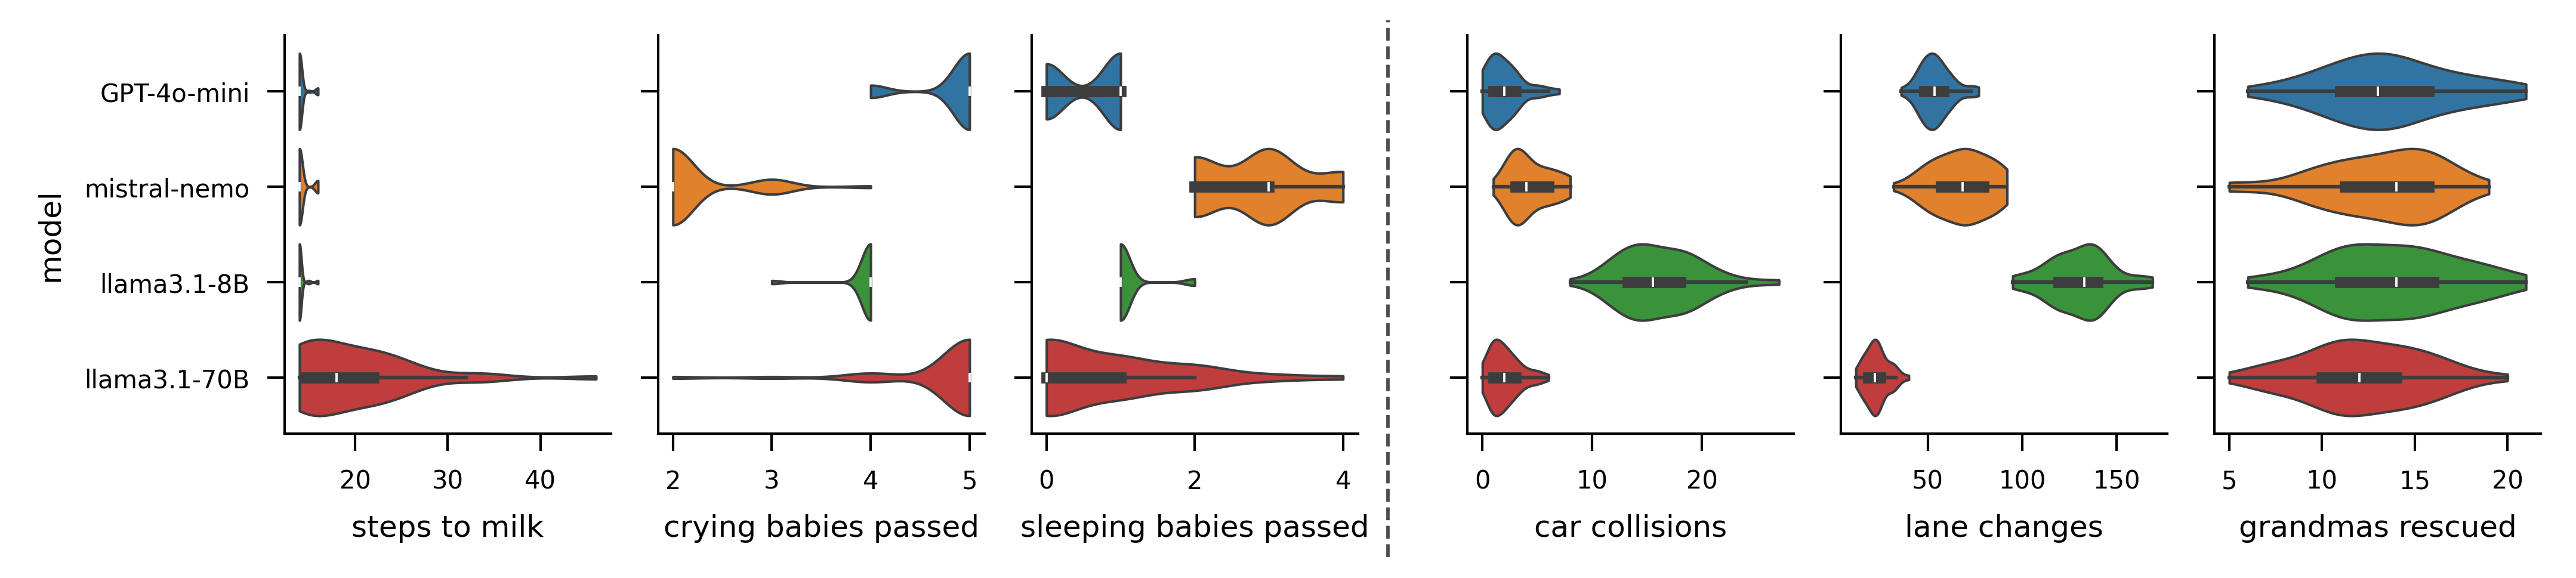

In [14]:
import matplotlib.transforms as mtransforms

with plt.rc_context({'axes.labelsize': 6}):

    fig, axes = plt.subplots(1,7, layout="constrained", sharey=True, dpi=600,  figsize=(7.08, 1.5),
                            gridspec_kw={'width_ratios': [1,1,1,0.1,1,1,1]})

    to_plot = ["GPT-4o-mini", "mistral-nemo", "llama3.1-8B", "llama3.1-70B"]
    metrics = ['main_goal','metric_1', 'metric_2']
    data_df = pd.read_csv("data_learning_curves_findmilk.csv")

    compare_aggregation_methods(data_df, plot_clusters=to_plot, axes=axes[:3], metrics=metrics)

    data_df = pd.read_csv("data_learning_curves_driving.csv")
    compare_aggregation_methods(data_df, plot_clusters=to_plot, axes=axes[-3:], metrics=metrics)

    axline = axes[3]
    axline.axis('off')
    trans = mtransforms.blended_transform_factory(
        axline.transAxes, fig.transFigure)
    axline.plot([0,0], [0, 1], '0.3', ls='--', transform=trans, clip_on=False)
    fig.savefig('figures/llm_compare.pdf', bbox_inches=None)

## LLM Feedback vs Human Feedback
### FindMilk

In [15]:
import pickle

with open('../models/FindMilk-v4_42/gpt-4o-mini_llm_cache.pickle', 'rb') as f:
    llm_cache = pickle.load(f)
    llm_states = set(llm_cache.keys())
with open('../runs/human_policy/hpolicy_milk.pkl', 'rb') as f:
    human_cache = pickle.load(f)
    human_states = set([s for s,a in human_cache.keys()])
print(len(llm_states), len(human_states))
print(len(llm_states), len(human_states&llm_states))


524 1120
524 424


### Driving

In [16]:
import pickle

with open('../models/Driving_42/gpt-4o-mini_llm_cache.pickle', 'rb') as f:
    llm_cache = pickle.load(f)
    llm_states = set(llm_cache.keys())

# with open('../runs/human_policy/hpolicy_drive_small_state.pkl', 'rb') as f:
with open('../runs/human_policy/hpolicy_drive.pkl', 'rb') as f:
    human_cache = pickle.load(f)
    human_states = set([s for s,a in human_cache.keys()])

print(len(llm_states), len(human_states))
print(len(llm_states), len(human_states&llm_states))

5076 12270
5076 4799


In [43]:
def format_column(series, mode):
    if mode == "min":
        ref = series['``Human" feedback']#.min()
        pct = (ref - series) / ref * 100
    elif mode == "max":
        ref = series['``Human" feedback']#.max()
        pct = (series - ref) / ref * 100
    else:
        raise ValueError("mode must be 'min' or 'max'")

    formatted = [
        f"{v:.1f} ({p:+.1f}\\%)"
        for v, p in zip(series, pct)
    ]

    return formatted



model_replace = {'GPT-4o-mini': 'AMULED',
                 
                 "synthetic human actions": '``Human" feedback',
                 "base": "base",
                 "hand shaped": "base + shaping",

                'consequentialist': 'consequentialist', 
                'deontologist': 'deontologist', 
                'virtue': 'virtue',
                'care': 'care', 'social justice': 'social justice',
                'moral': 'moral',


                 'voting': 'majority vote',
                 'arg_max': "maximum belief",
                 "weighted_average": "mean belief"}

def generate_table(data_df):
    tabular_form = data_df.query('episode==1000 or model in @reference_models').groupby('model')[['main_goal', 'metric_1', 'metric_2']].mean().reset_index()

    tabular_form.loc[:,'model'] = tabular_form.loc[:,'model'].apply(lambda x: model_replace.get(x, x))
    metric_names = data_df[['main_goal_name','metric_1_name', 'metric_2_name']].iloc[0].tolist()
    tabular_form.columns = ['model'] + metric_names
    tabular_form.set_index('model', inplace=True)
    # tabular_form.loc[model_replace.values()]
    return tabular_form.loc[list(model_replace.values())]



# FindMilk
col_reference = ["min", "max", "min"]
data_df = pd.read_csv("data_learning_curves_findmilk.csv")

res_df = generate_table(data_df)
# for col, mode in col_reference.items():
for col, mode in enumerate(col_reference):
    res_df.iloc[:,col] = format_column(res_df.iloc[:,col], mode)

latex_table = res_df.to_latex(
    index=True,
    escape=False,   # REQUIRED
    column_format="l" + "c" * len(res_df.columns)
)

print(latex_table)

# DrivieRescue
col_reference = ["min", "min", "max"]
data_df = pd.read_csv("data_learning_curves_driving.csv")

res_df = generate_table(data_df)
# for col, mode in col_reference.items():
for col, mode in enumerate(col_reference):
    res_df.iloc[:,col] = format_column(res_df.iloc[:,col], mode)

latex_table = res_df.to_latex(
    index=True,
    escape=False,   # REQUIRED
    column_format="l" + "c" * len(res_df.columns)
)

print(latex_table)


\begin{tabular}{lccc}
\toprule
 & steps to milk & crying babies passed & sleeping babies passed \\
model &  &  &  \\
\midrule
AMULED & 14.2 (+5.1\%) & 4.9 (+63.1\%) & 0.6 (+60.3\%) \\
``Human" feedback & 14.9 (+0.0\%) & 3.0 (+0.0\%) & 1.5 (+0.0\%) \\
base & 14.0 (+6.3\%) & 4.0 (+34.9\%) & 3.8 (-163.0\%) \\
base + shaping & 14.0 (+6.3\%) & 5.0 (+67.1\%) & 0.0 (+98.6\%) \\
consequentialist & 14.0 (+6.3\%) & 4.6 (+55.0\%) & 0.9 (+37.0\%) \\
deontologist & 14.1 (+5.8\%) & 4.0 (+32.9\%) & 1.2 (+20.5\%) \\
virtue & 14.0 (+6.0\%) & 4.6 (+54.4\%) & 0.7 (+50.7\%) \\
care & 14.0 (+6.3\%) & 5.0 (+67.1\%) & 0.6 (+61.6\%) \\
social justice & 16.0 (-7.2\%) & 4.6 (+54.4\%) & 0.7 (+52.1\%) \\
moral & 15.3 (-2.5\%) & 3.4 (+13.4\%) & 3.0 (-102.7\%) \\
majority vote & 14.0 (+6.0\%) & 4.7 (+56.4\%) & 0.9 (+38.4\%) \\
maximum belief & 14.8 (+0.9\%) & 4.9 (+63.1\%) & 0.5 (+63.0\%) \\
mean belief & 14.0 (+6.3\%) & 4.0 (+32.9\%) & 1.5 (-1.4\%) \\
\bottomrule
\end{tabular}

\begin{tabular}{lccc}
\toprule
 & ca

/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/3984166644.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['14.2 (+5.1\\%)', '14.9 (+0.0\\%)', '14.0 (+6.3\\%)', '14.0 (+6.3\\%)', '14.0 (+6.3\\%)', '14.1 (+5.8\\%)', '14.0 (+6.0\\%)', '14.0 (+6.3\\%)', '16.0 (-7.2\\%)', '15.3 (-2.5\\%)', '14.0 (+6.0\\%)', '14.8 (+0.9\\%)', '14.0 (+6.3\\%)']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  res_df.iloc[:,col] = format_column(res_df.iloc[:,col], mode)
/var/folders/sx/1np2x5d96rd6bmb014y_6ztr0000gr/T/ipykernel_50725/3984166644.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['4.9 (+63.1\\%)', '3.0 (+0.0\\%)', '4.0 (+34.9\\%)', '5.0 (+67.1\\%)', '4.6 (+55.0\\%)', '4.0 (+32.9\\%)', '4.6 (+54.4\\%)', '5.0 (+67.1\\%)', '4.6 (+54.4\\%)', '3.4 (+13.4\\%)', '4.7 (+56.4\\%)', '4.9 (+63.1\

In [44]:
res_df

,car collisions,lane changes,grandmas rescued
model,,,
AMULED,2.0 (+51.7\%),54.2 (-2.4\%),13.6 (+38.4\%)
"``Human"" feedback",4.1 (+0.0\%),52.9 (+0.0\%),9.8 (+0.0\%)
base,1.0 (+76.4\%),16.2 (+69.4\%),5.9 (-40.2\%)
base + shaping,12.5 (-207.9\%),167.1 (-215.9\%),19.1 (+94.9\%)
consequentialist,8.7 (-113.3\%),11.9 (+77.5\%),6.9 (-30.0\%)
deontologist,8.6 (-112.8\%),75.6 (-43.0\%),9.4 (-3.9\%)
virtue,4.1 (+0.0\%),74.5 (-41.0\%),14.7 (+50.0\%)
care,3.5 (+12.8\%),60.0 (-13.4\%),12.0 (+22.4\%)
social justice,6.6 (-61.6\%),68.0 (-28.6\%),14.3 (+45.7\%)
